$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE (DS-UA 201)}\\\\
\textbf{Lab 5: Experiments}\\
\textit{Center for Data Science, New York University}\\\\
\end{array}
$$

---

# Experiments: From Randomization to an Estimated Causal Effect

By the end of this lab you should be able to:

1. Explain why a simple comparison of treated and untreated people (observational data) is usually *not* a causal effect, using the idea of **selection bias**.
2. Explain how **randomization**, plus the assumptions of **perfect compliance** and **SUTVA**, lets us **identify** the Average Treatment Effect (ATE).
3. **Estimate** the ATE from a sample using a difference in conditional sample means.
4. Gauge our **confidence** in that estimate with a two-sample t-test (and a confidence interval).
5. Test our assumptions with a **balance test**, and say what a balance test can and cannot prove.
6. Explain what to do when compliance is imperfect (the **Intent to Treat** effect) and when SUTVA fails (**spillovers** and **cluster randomization**).

## Data file

You need the data file **`NSW_Data.dta`** in the same folder as this notebook. You can download it from my GitHub for this week.

---
# Part 1. The big picture

## 1.1 The three steps of answering a causal question

Every method in this course follows the same three steps. Keep them in mind, because the whole lab is organized around them.

| Step | Question it answers | In this lab |
|---|---|---|
| **1. Define** the causal parameter | *What* number do we want to know? | The ATE of a job training program on wages |
| **2. Identify** the parameter | Can we write that number using things we *could* observe? | Randomization lets us write the ATE as a difference of two conditional expectations |
| **3. Estimate** the parameter | How do we compute it from an actual sample? | A difference of two conditional sample means |

Experiments are the first method we use to get through all three steps. They are used everywhere: social scientists call them **lab experiments** (in a lab) or **randomized controlled trials, RCTs** (out in the world, "in the field"); medical researchers call them **clinical trials**.

## 1.2 Notation

- $S \in \{0, 1\}$ is the **treatment**. $S = 1$ means a unit (a person, a school, a website visitor) gets the treatment; $S = 0$ means it does not.
- $U$ is **everything else** that might affect the outcome: age, education, motivation, luck, and so on.
- $Y(S, U)$ is the **potential outcome**: the outcome a unit would have with treatment status $S$ and other factors $U$.

Each unit has two potential outcomes, $Y(1, U)$ and $Y(0, U)$. The causal effect for that unit is the difference between them. Our target is the average of that difference over the population, the **Average Treatment Effect**:

$$
\text{ATE} = \mathbb{E}\big[\,Y(S = 1, U) - Y(S = 0, U)\,\big].
$$

The fundamental problem of causal inference: we only ever see *one* of the two potential outcomes for each unit. A person who took the job training shows us $Y(1, U)$; we never see what they would have earned without it. So we can never compute $\mathbb{E}[Y(1,U)]$ or $\mathbb{E}[Y(0,U)]$ directly for the whole population.

## 1.3 Why not just compare people? Selection bias

Suppose we use **observational data**: data that arises naturally from people's day-to-day choices. The obvious thing to compute is the difference in average outcomes between people who happened to be treated and people who were not:

$$
\mathbb{E}[Y(1, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0].
$$

Is that the causal effect? Let's check by adding and subtracting the same term, $\mathbb{E}[Y(0, U) \mid S = 1]$ (adding zero never changes anything):

$$
\begin{aligned}
&\mathbb{E}[Y(1, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0] \\
&= \underbrace{\mathbb{E}[Y(1, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 1]}_{\text{ATT: effect on the people who were treated}}
\;+\; \underbrace{\mathbb{E}[Y(0, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0]}_{\text{Selection bias}}.
\end{aligned}
$$

Read the selection bias term in words: *"How different would the treated group's outcomes be from the untreated group's outcomes **if nobody had been treated at all**?"* If the kind of people who choose treatment differ from the kind who do not, this term is not zero, and the simple comparison mixes the real effect with pre-existing differences.

**The job training example.** Let $Y$ be annual wages and $S = 1$ if a worker used a job training program. Who signs up for job training? Mostly workers who are struggling to find or keep work. Even without the program, they would likely earn *less* than workers who do not sign up. So

$$
\mathbb{E}[Y(0, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0] < 0,
$$

and the selection bias is **negative**. This is exactly why early observational studies often found that job training programs were associated with *lower* wages: the negative selection bias swamped any positive effect of the training itself.

## 1.4 The fix: randomization (plus two assumptions)

In an experiment, *we* decide who gets treated, and we decide **at random**, with no regard to anyone's characteristics. Randomization breaks any link between who is treated and everything else about them. To make that argument, we lean on two assumptions.

**Perfect compliance.** Everyone assigned $S = 1$ actually gets the treatment, and everyone assigned $S = 0$ does not. This is reasonable in a lab, or in an A/B test where users cannot choose which version of a website they see. It is harder to believe when people can opt in or out on their own: if a doctor randomly tells some patients to exercise, some untold patients will exercise anyway, and some told patients will not. Without compliance, the treatment people *actually receive* is partly their own choice again, so it is not random.

**SUTVA (Stable Unit Treatment Value Assumption).** A unit's outcome depends only on its own treatment, not on anyone else's. This is plausible in a medical trial where patients never meet. It is less plausible if, say, we teach a random set of farmers in a village a new technique and they tell their neighbors. SUTVA keeps the definition of $S$ clean: $S$ really is individual exposure to treatment.

With randomization, perfect compliance, and SUTVA, we can make the crucial assumption

$$
S \perp\!\!\!\perp U,
$$

"treatment is **independent** of everything else that affects the outcome."

## 1.5 Identifying the ATE

Because $S \perp\!\!\!\perp U$, the treated group is a random slice of the population, so its average outcome *with treatment* is the population's average outcome with treatment. The same holds for the control group without treatment:

$$
\mathbb{E}[Y(1, U) \mid S = 1] = \mathbb{E}[Y(1, U)], \qquad \mathbb{E}[Y(0, U) \mid S = 0] = \mathbb{E}[Y(0, U)].
$$

So the comparison we *can* compute equals the ATE:

$$
\begin{aligned}
\mathbb{E}[Y(1, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0]
&= \mathbb{E}[Y(1, U)] - \mathbb{E}[Y(0, U)] \\
&= \mathbb{E}[Y(1, U) - Y(0, U)] \quad \text{(linearity of expectation)} \\
&= \text{ATE}.
\end{aligned}
$$

The ATE is **identified**: we wrote it entirely in terms of conditional expectations that we can estimate from data.

**What happened to the selection bias term?** Under independence, $\mathbb{E}[Y(0, U) \mid S = 1] = \mathbb{E}[Y(0, U) \mid S = 0]$: without treatment, the two randomly formed groups would have the same average outcome. So the selection bias term is exactly zero. Randomization did not make people the same; it made the *groups* the same on average.


---
# Part 2. The NSW job training experiment (LaLonde, 1986)

In the 1970s it was unclear whether government job training programs helped workers. Observational comparisons often suggested they *hurt* (the negative selection bias from Part 1). So the government ran an experiment, the **National Supported Work (NSW) Demonstration**:

- Disadvantaged workers **applied** to the program.
- Among qualified applicants, some were **randomly** admitted and others were **randomly** denied.
- The program guaranteed a short period of employment plus meetings with counsellors.
- Surveyors followed up with **both** groups to record their later wages.

Robert LaLonde (1986) used this data to show that the experiment and the observational methods of the day gave very different answers. We will replicate the experimental estimate.

**Defining our terms for this study**

| Symbol | Meaning | Column in the data |
|---|---|---|
| $S$ | 1 if admitted to the NSW program, 0 if not | `treat` |
| $Y(S, U)$ | Real annual earnings in 1978, about two years after training | `re78` |
| $U$ | Everything else that affects wages | (partly observed: `age`, `education`, ...) |

**Are our assumptions reasonable here?**

- *Perfect compliance:* there was no way to sneak into the program without being admitted, and it is unlikely that admitted applicants turned down free work. In principle, researchers could confirm this by following up.
- *SUTVA:* could training some workers change local job markets for the others? Possibly, but the experiment was small relative to the labor market, so we assume not.

Our **population** is the set of people who applied to the NSW, so the ATE we identify is the average effect of the program for applicants like these, not for all workers in the US.

## 2.1 Setting up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

## 2.2 Loading the data

In [3]:
DATA_PATH = "NSW Data.dta"   # change this if your file has a different name

data = pd.read_stata(DATA_PATH)
data.head()

,data_id,treat,age,education,black,hispanic,married,nodegree,re75,re78
0,Lalonde Sample,1,37,11,1,0,1,1,0.0,9930.045898
1,Lalonde Sample,1,22,9,0,1,0,1,0.0,3595.894043
2,Lalonde Sample,1,30,12,1,0,0,0,0.0,24909.449219
3,Lalonde Sample,1,27,11,1,0,0,1,0.0,7506.145996
4,Lalonde Sample,1,33,8,1,0,0,1,0.0,289.789886


### The code explained

- `DATA_PATH = "NSW_Data.dta"` stores the file name in a variable. Putting it at the top makes it easy to change in one place.
- `pd.read_stata(DATA_PATH)` reads a **Stata** file (extension `.dta`, a format common in economics) and returns a pandas DataFrame. We store it in a variable called `data`.
- `data.head()` shows the **first five rows**. Always look at your data before analyzing it: you can check that the columns are what you expect.

**What the columns mean**

| Column | Meaning |
|---|---|
| `data_id` | Label for the sample (every row says "Lalonde Sample") |
| `treat` | 1 if admitted to the NSW program (treatment group), 0 if not (control group) |
| `age`, `education` | Age in years, years of schooling |
| `black`, `hispanic`, `married` | 1 if true, 0 if not |
| `nodegree` | 1 if the person has no high school degree |
| `re75` | Real earnings in 1975, **before** the program |
| `re78` | Real earnings in 1978, **after** the program (our outcome $Y$) |

## 2.3 A first look

In [3]:
data.describe()

,treat,age,education,black,hispanic,married,nodegree,re75,re78
count,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000
mean,0.411357,24.520776,10.267313,0.800554,0.105263,0.162050,0.779778,3042.896484,5454.635742
std,0.492421,6.625947,1.704774,0.399861,0.307105,0.368752,0.414683,5066.143066,6252.943359
min,0.000000,17.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,19.000000,9.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,23.000000,10.000000,1.000000,0.000000,0.000000,1.000000,936.307953,3951.889038
75%,1.000000,27.000000,11.000000,1.000000,0.000000,0.000000,1.000000,3993.206970,8772.004395
max,1.000000,55.000000,16.000000,1.000000,1.000000,1.000000,1.000000,37431.660156,60307.929688


Two things worth noticing. The mean of `treat` is about 0.41, so about 41% of the sample was treated (a mean of a 0/1 variable is the share of 1s). And the 25th percentile of `re78` is 0: more than a quarter of the sample earned nothing in 1978, which tells us this is a very disadvantaged population.

In [4]:
data["treat"].value_counts()

treat
0    425
1    297
Name: count, dtype: int64


- `data["treat"]` selects the single column called `treat`.
- `.value_counts()` counts how many times each value appears.

The output shows **297 people in the treatment group** (`treat = 1`) and **425 in the control group** (`treat = 0`), for 722 in total. The groups do not need to be the same size for randomization to work; what matters is that *who* ended up in each group was decided at random.

---
# Part 3. Estimating the ATE

## 3.1 From expectations to sample means

In Part 1 we showed that, if $S \perp\!\!\!\perp U$,

$$
\text{ATE} = \mathbb{E}[Y(1, U) \mid S = 1] - \mathbb{E}[Y(0, U) \mid S = 0].
$$

We cannot compute a population expectation, but we can estimate it. Earlier in the course we saw that the **sample mean** is a consistent and unbiased estimator of the expectation. In the same way, the **conditional sample mean** (the average among only the units that satisfy the condition) is a consistent and unbiased estimator of the **conditional expectation**.

For units $i = 1, \dots, n$ with outcomes $Y_i$ and treatment indicators $S_i$:

$$
\hat{\mathbb{E}}[Y(1, U) \mid S = 1] = \frac{1}{\sum_{i=1}^n S_i} \sum_{i=1}^n Y_i S_i,
\qquad
\hat{\mathbb{E}}[Y(0, U) \mid S = 0] = \frac{1}{\sum_{i=1}^n (1 - S_i)} \sum_{i=1}^n Y_i (1 - S_i).
$$

These look scary but are just "average of $Y$ among the treated" and "average of $Y$ among the controls":

- $\sum_i S_i$ counts the treated units (each treated unit adds 1, each control adds 0).
- $\sum_i Y_i S_i$ adds up the outcomes of treated units only (multiplying by $S_i = 0$ removes the controls).
- Replacing $S_i$ with $1 - S_i$ does the same for the control group.

Our estimator of the ATE is the difference:

$$
\widehat{\text{ATE}} = \hat{\mathbb{E}}[Y(1, U) \mid S = 1] - \hat{\mathbb{E}}[Y(0, U) \mid S = 0].
$$

Because each piece is consistent and unbiased, so is the difference. In practice this is called the **difference-in-means estimator**.

## 3.2 Computing it

In [5]:
treated = data[data["treat"] == 1]
control = data[data["treat"] == 0]

mean_treated = treated["re78"].mean()
mean_control = control["re78"].mean()
ate_hat = mean_treated - mean_control

print(f"Average 1978 earnings, treatment group: ${mean_treated:,.2f}")
print(f"Average 1978 earnings, control group:   ${mean_control:,.2f}")
print(f"Estimated ATE (difference in means):    ${ate_hat:,.2f}")

Average 1978 earnings, treatment group: $5,976.35
Average 1978 earnings, control group:   $5,090.05
Estimated ATE (difference in means):    $886.30


### The code explained

- `data["treat"] == 1` compares every value of `treat` to 1 and returns a column of `True`/`False` values, one per row.
- `data[ ... ]` with that True/False column inside the brackets keeps **only the rows that are `True`**. This is called *boolean indexing* or *filtering*. So `treated` is a smaller DataFrame with just the 297 treated people, and `control` has the 425 controls.
- `treated["re78"].mean()` takes the `re78` column of the treated group and averages it. This is $\hat{\mathbb{E}}[Y(1, U) \mid S = 1]$, the conditional sample mean.
- `ate_hat = mean_treated - mean_control` is $\widehat{\text{ATE}}$.

To connect the code to the formula, here is the exact same estimate computed with the sums from Section 3.1. It should print the same number.

In [6]:
S = data["treat"]
Y = data["re78"]

mean_treated_formula = (Y * S).sum() / S.sum()
mean_control_formula = (Y * (1 - S)).sum() / (1 - S).sum()

print(f"Estimated ATE using the formula: ${mean_treated_formula - mean_control_formula:,.2f}")

Estimated ATE using the formula: $886.30


### The code explained

- `S` and `Y` are the treatment column and the outcome column, named to match the math.
- `Y * S` multiplies the two columns row by row. For a treated person this gives their earnings ($Y_i \times 1$); for a control it gives 0 ($Y_i \times 0$).
- `.sum()` adds up a column, so `(Y * S).sum()` is $\sum_i Y_i S_i$ and `S.sum()` is $\sum_i S_i$, the number of treated people.
- `1 - S` flips the indicator: it is 1 for controls and 0 for treated. That gives the control-group mean.

Both approaches give **\$886.30**: filtering rows and averaging is exactly what the formula describes.

## 3.3 Interpreting the estimate

> On average, being admitted to the NSW program **increased** 1978 earnings by about **\$886** (in 1978 dollars) among the applicants in this study.

For context, the control group earned about \$5,090 on average, so this is roughly a 17% increase. Note the sign: the observational studies of the time suggested job training *lowered* wages. Randomization removed the negative selection bias and revealed a positive effect.

But \$886 is an **estimate** from one sample. A different random draw of applicants would give a different number. How sure are we that the true ATE is above zero?

---
# Part 4. How confident are we? The two-sample t-test

## 4.1 Why we can do a test at all

The **Central Limit Theorem (CLT)** tells us that, with a large i.i.d. sample, the sample mean is approximately normally distributed around the true expectation. That lets us quantify how much a sample mean bounces around from sample to sample.

A **two-sample t-test** extends this to comparing two means. It requires two i.i.d. samples that are independent of each other. Our treatment and control groups can be treated as independent precisely because assignment was random.

## 4.2 The hypotheses

We want to know whether the program *increased* wages, so we test:

$$
\begin{aligned}
H_0 &: \mathbb{E}[Y(1, U)] = \mathbb{E}[Y(0, U)] \quad \Longleftrightarrow \quad \text{ATE} = 0 \\
H_1 &: \mathbb{E}[Y(1, U)] > \mathbb{E}[Y(0, U)] \quad \Longleftrightarrow \quad \text{ATE} > 0
\end{aligned}
$$

This is a one-sided test. Instead of asking "are the means different in either direction?", we ask "is the treated mean bigger?" We choose one-sided because the question we care about is whether the program helped.

In [7]:
t_result = stats.ttest_ind(
    treated["re78"],
    control["re78"],
    alternative="greater",
    equal_var=False,
)
t_result

TtestResult(statistic=1.8154352445974968, pvalue=0.03499729752278968, df=557.0617000675076)

### The code explained

`stats.ttest_ind` runs a two-sample t-test (`ind` stands for *independent* samples). Its syntax is

```
stats.ttest_ind(first_sample, second_sample, alternative=..., equal_var=...)
```

- `treated["re78"]`, `control["re78"]`: the **two required arguments**, the two samples we compare. Order matters for a one-sided test, because the test is about the *first* sample relative to the second.
- `alternative="greater"`: makes it a **one-sided** test of whether the mean of the first sample (treated) is greater than the mean of the second (control). The default, `"two-sided"`, tests for a difference in either direction; `"less"` tests whether the first mean is smaller.
- `equal_var=False`: tells the test **not** to assume both groups have the same variance. The default is `True`, which is rarely a good assumption: there is no reason the spread of wages should be identical in both groups. With `False`, SciPy runs **Welch's t-test**, which allows different variances. Always set this explicitly.

The result has three parts:

- `statistic` (about 1.82): the **t-statistic**, the difference in means divided by its standard error. It measures how many standard errors apart the two means are.
- `pvalue` (about 0.035): the **p-value**.
- `df` (about 557): degrees of freedom used by Welch's test. You can ignore this for interpretation.

## 4.3 Interpreting the result

The p-value is about **0.035**. In words: *if the program truly had no effect (ATE = 0), there would only be about a 3.5% chance of drawing a sample where the treated group out-earns the control group by this much or more.*

Since 0.035 < 0.05, we **reject the null hypothesis** at the 5% significance level. This is fairly strong evidence that the difference is not just chance, and that the NSW program causally increased wages.

A p-value is not "the probability that the null is true." It is a statement about how surprising our data would be *if* the null were true.

## 4.4 Going further: a confidence interval

A p-value answers a yes/no question. A **confidence interval** tells us the range of ATE values that are consistent with the data, which is often more useful. For a difference in means, the standard error is

$$
\text{SE}\big(\widehat{\text{ATE}}\big) = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}},
$$

where $s_1^2, n_1$ are the sample variance and size of the treatment group and $s_0^2, n_0$ those of the control group. An approximate 95% confidence interval is $\widehat{\text{ATE}} \pm 1.96 \times \text{SE}$.

In [8]:
n1, n0 = len(treated), len(control)
var1, var0 = treated["re78"].var(), control["re78"].var()

se = np.sqrt(var1 / n1 + var0 / n0)
ci_low, ci_high = ate_hat - 1.96 * se, ate_hat + 1.96 * se

print(f"Standard error of the ATE estimate: ${se:,.2f}")
print(f"t-statistic (ATE / SE): {ate_hat / se:.3f}")
print(f"Approximate 95% confidence interval: [${ci_low:,.2f}, ${ci_high:,.2f}]")

Standard error of the ATE estimate: $488.20
t-statistic (ATE / SE): 1.815
Approximate 95% confidence interval: [$-70.58, $1,843.18]


### The code explained

- `len(treated)` counts the rows (people) in the treated DataFrame, giving $n_1 = 297$; `len(control)` gives $n_0 = 425$.
- `.var()` computes the **sample variance** of a column.
- `np.sqrt(...)` takes the square root, giving the standard error formula above.
- `ate_hat / se` reproduces the **t-statistic** from `ttest_ind` (about 1.815). This shows what the t-test is doing under the hood.
- `1.96` is the value that leaves 2.5% in each tail of a standard normal distribution, which is what makes the interval a 95% interval.

**Interpretation.** The interval runs from about **−\$71 to \$1,843**. Notice that it **includes zero**, even though the one-sided test rejected the null. These are not contradictory. A 95% two-sided interval corresponds to a *two-sided* test at the 5% level, which splits the 5% across both tails. The two-sided p-value here is about 2 × 0.035 = 0.07, just above 0.05. Our one-sided test puts all 5% in the "greater" tail, so it rejects. The lesson: decide *before* looking at the data whether your question is one-sided or two-sided, and report which one you used.

## 4.5 Why this mattered

Earlier observational studies had found **negative** effects of job training. LaLonde showed that the randomized experiment found a **positive** effect, and that the observational methods of the time could not reproduce it. Without randomization, the attempts to measure the causal effect of training had been misled by **selection bias**.

---
# Part 5. Testing our assumptions

Our identification relied on $S \perp\!\!\!\perp U$, which was supported by perfect compliance (and SUTVA keeps $S$ well defined). We can rarely prove an identifying assumption, but it is always good practice to look for **supporting evidence**.

## 5.1 Testing compliance

Compliance is something the people running an experiment can check: follow up with subjects to see whether they did what they were assigned. **Objective** evidence (attendance records, pharmacy refills, app logs) is better than simply asking people, who may not answer accurately. Our dataset does not contain compliance records, so we take the NSW design argument from Part 2 at face value.

## 5.2 Testing independence: the balance test

If $S \perp\!\!\!\perp U$, then $U$ should have the same distribution in both groups. In particular,

$$
\mathbb{E}[U \mid S = 1] = \mathbb{E}[U \mid S = 0].
$$

We cannot see all of $U$, but we can see some of it: **observable characteristics** such as age and education. A **balance test** compares the distribution of these observables between the treatment and control groups. If randomization worked, they should look alike.

Balance tests usually focus on variables that are plausibly **part of $U$**, meaning they likely affect the outcome. Education almost certainly affects wages, so if education is balanced, that is supporting evidence that $U$ as a whole is balanced.

We start by looking at the distributions, then test the means formally.

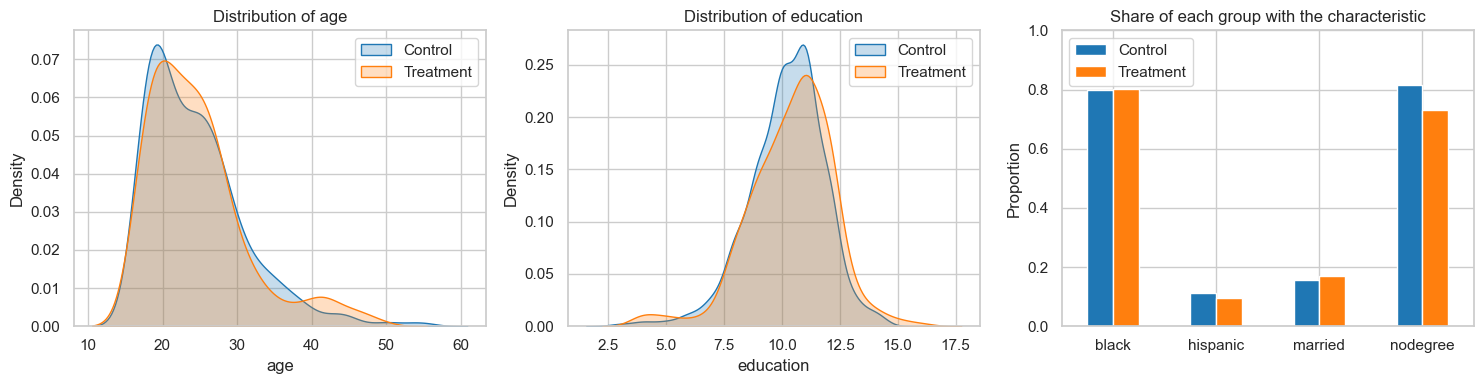

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes[:2], ["age", "education"]):
    sns.kdeplot(control[var], ax=ax, fill=True, label="Control", color="tab:blue")
    sns.kdeplot(treated[var], ax=ax, fill=True, label="Treatment", color="tab:orange")
    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)
    ax.legend()

dummy_vars = ["black", "hispanic", "married", "nodegree"]
shares = data.groupby("treat")[dummy_vars].mean().T
shares.columns = ["Control", "Treatment"]
shares.plot(kind="bar", ax=axes[2], color=["tab:blue", "tab:orange"], rot=0)
axes[2].set_title("Share of each group with the characteristic")
axes[2].set_ylabel("Proportion")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### The code explained

- `plt.subplots(1, 3, figsize=(15, 4))` creates a figure with **1 row and 3 panels** (called *axes*), 15 by 4 inches. `fig` is the whole figure; `axes` is a list of the three panels.
- `zip(axes[:2], ["age", "education"])` pairs the first two panels with the two continuous variables, so the loop draws `age` in panel 1 and `education` in panel 2.
- `sns.kdeplot(...)` draws a **kernel density estimate**, a smoothed histogram. We draw one for each group on the same panel (`ax=ax`) so they can be compared directly. `fill=True` shades the area under the curve.
- For the 0/1 variables, a density plot is not meaningful, so we compare **proportions** instead:
  - `data.groupby("treat")[dummy_vars].mean()` splits the data by `treat` and averages each dummy variable within each group. The average of a 0/1 variable is the share of people with that characteristic.
  - `.T` **transposes** the table (swaps rows and columns) so each characteristic becomes a row, which is the shape pandas needs for a grouped bar chart.
  - `shares.plot(kind="bar", ...)` draws side-by-side bars for the two groups.
- `plt.tight_layout()` stops panels from overlapping; `plt.show()` displays the figure.

**Notice** the age and education distributions for the two groups almost lie on top of each other, and the shares are very close for `black`, `hispanic`, and `married`. The one visible gap is `nodegree`: the treatment group has a somewhat lower share of people without a high school degree. Let's test that formally.

### The formal balance test

For each observable $X$ (whichever background characteristic we are testing; a part of U) we run a two-sample t-test of

$$
H_0: \mathbb{E}[X \mid S = 1] = \mathbb{E}[X \mid S = 0] \qquad \text{vs.} \qquad H_1: \mathbb{E}[X \mid S = 1] \neq \mathbb{E}[X \mid S = 0].
$$

This time the test is **two-sided**: we have no reason to expect imbalance in one particular direction, and imbalance in either direction would worry us. A large p-value means we find no evidence of a difference, which is what we hope to see.

We also report the **standardized mean difference**:

$$
= \frac{\bar{X}_{\text{treat}} - \bar{X}_{\text{control}}}{\sqrt{(s^2_{\text{treat}} + s^2_{\text{control}})/2}}.
$$

The Standardized Mean Difference measures the gap in units of standard deviations, so it does **not** depend on sample size the way a p-value does. A common rule of thumb is that $|\text{SMdiff}| < 0.1$ indicates good balance.

We include `re75`, earnings in **1975, before the program**. This is a **past outcome**, and Section 5.3 explains why it is especially useful.

In [10]:
covariates = ["age", "education", "black", "hispanic", "married", "nodegree", "re75"]

rows = []
for var in covariates:
    x_treat = treated[var]
    x_control = control[var]

    t_stat, p_value = stats.ttest_ind(x_treat, x_control, equal_var=False)
    pooled_sd = np.sqrt((x_treat.var() + x_control.var()) / 2)
    smd = (x_treat.mean() - x_control.mean()) / pooled_sd

    rows.append({
        "Variable": var,
        "Control mean (SD)": f"{x_control.mean():.2f} ({x_control.std():.2f})",
        "Treatment mean (SD)": f"{x_treat.mean():.2f} ({x_treat.std():.2f})",
        "SMD": round(smd, 3),
        "p-value": round(p_value, 3),
    })

balance_table = pd.DataFrame(rows)
balance_table

,Variable,Control mean (SD),Treatment mean (SD),SMD,p-value
0,age,24.45 (6.59),24.63 (6.69),0.027,0.722
1,education,10.19 (1.62),10.38 (1.82),0.112,0.144
2,black,0.80 (0.40),0.80 (0.40),0.003,0.965
3,hispanic,0.11 (0.32),0.09 (0.29),-0.061,0.415
4,married,0.16 (0.36),0.17 (0.37),0.029,0.703
5,nodegree,0.81 (0.39),0.73 (0.44),-0.200,0.009
6,re75,3026.68 (5201.25),3066.10 (4874.89),0.008,0.917


### The code explained

- `covariates` is the list of observable characteristics we want to check.
- `rows = []` starts an empty list. Each pass through the loop adds one dictionary (one row of the final table) to it.
- Inside the loop, for one variable at a time:
  - `x_treat` and `x_control` are that variable's values in each group.
  - `stats.ttest_ind(x_treat, x_control, equal_var=False)` is the same Welch t-test as in Part 4, but **without** `alternative=`, so it uses the default two-sided test. The function returns two numbers, which we unpack into `t_stat` and `p_value`.
  - `pooled_sd` and `smd` implement the SMD formula above.
  - `.std()` is the standard deviation; we show it in parentheses next to each mean, which is the standard way balance tables are reported (LaLonde's Table 1 does the same).
  - `rows.append({...})` adds a dictionary whose keys become column names.
- `pd.DataFrame(rows)` turns the list of dictionaries into a table.

### Interpreting the balance table

Take `education` as an example: the control group averages 10.19 years of schooling and the treatment group 10.38. The p-value is 0.14, so we **fail to reject** equal means. The Standardized Mean Difference of 0.11 sits right at the 0.1 rule of thumb, so it is borderline, but a gap of a fifth of a year of schooling is small in practical terms. Education is plausibly part of $U$, so this is supporting evidence that randomization worked.

The other variables look even better: `age`, `black`, `hispanic`, `married`, and `re75` all have small Standardized Mean Differences and large p-values. The exception is **`nodegree`** (p ≈ 0.009, SMD ≈ −0.20): 73% of the treatment group lacks a high school degree versus 81% of the control group. How worried should we be?

- **Some imbalance is expected by chance.** We ran 7 tests. Even with perfect randomization, each test has a 5% chance of a "significant" result, so seeing one out of seven is not unusual. When you run many tests, judge the overall pattern, not a single p-value.
- **The rest of the evidence points to good balance**, including the closely related `education` variable and pre-program earnings.
- **It is still worth flagging.** Having a degree likely raises wages, so a treatment group with slightly more graduates could push our estimate up a bit. In a later lab we will see how **regression** can adjust for observed covariates like this one.


## 5.3 The limits of balance tests

Balance tests are useful and you should always report one, but they **cannot fully prove** $S \perp\!\!\!\perp U$.

The main reason: they only tell us about **observables**. They say nothing about **unobservables**, characteristics the analyst cannot see. Suppose the staff doing the "randomization" quietly tended to admit friendlier applicants. Friendliness might raise future earnings, but there is no `friendliness` column to test.

**One partial check: past outcomes.** Stable unobservable traits (friendliness, motivation, work ethic) would likely have affected the outcome *before* the experiment too. So if **past outcomes** are balanced, that is evidence that unobservables are balanced as well. In our data, 1975 earnings (`re75`) average \$3,066 in the treatment group and \$3,027 in the control group, with an Standardized Mean Difference near zero and a p-value of about 0.92. If the groups differed on some hidden trait, it does not seem to have affected their earnings before the program. This is still not a proof, but it helps.

---
# Part 6. Relaxing perfect compliance: the Intent to Treat effect

## 6.1 The problem

Under **perfect compliance**, the treatment people receive equals the treatment they were assigned. We will write $Z$ for **assignment** (what we told people to do) and $S$ for the treatment they **actually received**.

```
Perfect compliance:      Z (assignment) ──► S (received) ──► Y (outcome)
                         S is exactly Z, so S is random.

Imperfect compliance:    Z (assignment) ──► S (received) ──► Y (outcome)
                                            ▲                ▲
                                            └──── U ─────────┘
                         People choose whether to comply, and that choice
                         depends on U, which also affects Y. S is no longer random.
```

With imperfect compliance, $S$ depends partly on people's own choices. If those choices relate to $U$ (and they usually do), then $S$ is **not** independent of $U$, and comparing people by the treatment they received brings selection bias right back.

## 6.2 The fix: change the target parameter

There are ways to try to recover the ATE despite non-compliance (we will see one, instrumental variables, later in the course). But a simple and very credible option is to **change the target parameter**.

The **Intent to Treat effect (ITT)** is the causal effect of being assigned to treatment, rather than the effect of the treatment itself. Writing $S_A$ for assignment:

$$
\text{ITT} = \mathbb{E}[Y(S_A = 1, U) - Y(S_A = 0, U)].
$$

Why does this help? People cannot "not comply" with being assigned. We control assignment completely, and we randomized it. So with proper randomization and SUTVA, $S_A \perp\!\!\!\perp U$ holds, and the ITT is identified by exactly the same argument as the ATE in Part 1:

$$
\text{ITT} = \mathbb{E}[Y \mid S_A = 1] - \mathbb{E}[Y \mid S_A = 0].
$$

In a sense, this is just redefining the treatment to be the assignment.

## 6.3 An example from the slides: being told to run

Suppose we want the effect of running three times a week on blood pressure. Doctors can randomly tell some patients to run, but they cannot force anyone to run or stop anyone from running. Some patients who are told will not follow through; some who are not told will run anyway. And the patients who actually run are likely the more motivated ones, and motivation also lowers blood pressure through other healthy habits.

The NSW data has (we assume) perfect compliance, so we simulate this scenario. The advantage of simulated data is that we know the true effect, so we can see which comparisons get it right. In our simulation:

- Running truly lowers blood pressure by 6 mmHg for anyone who runs.
- Higher motivation lowers blood pressure on its own, and makes people more likely to run.
- Assignment ("told to run") is randomized, half and half.

In [12]:
rng = np.random.default_rng(201)
n = 2000

motivation = rng.normal(0, 1, n)
told_to_run = rng.permutation(np.repeat([1, 0], n // 2))

prob_run_if_told = 1 / (1 + np.exp(-(0.5 + 1.5 * motivation)))
prob_run_if_not_told = 1 / (1 + np.exp(-(-2.0 + 1.5 * motivation)))
prob_run = np.where(told_to_run == 1, prob_run_if_told, prob_run_if_not_told)
ran = rng.binomial(1, prob_run)

TRUE_EFFECT_OF_RUNNING = -6
blood_pressure = 135 + TRUE_EFFECT_OF_RUNNING * ran - 4 * motivation + rng.normal(0, 8, n)

running = pd.DataFrame({
    "motivation": motivation,
    "told_to_run": told_to_run,
    "ran": ran,
    "blood_pressure": blood_pressure,
})

pd.crosstab(running["told_to_run"], running["ran"], margins=True)

ran,0,1,All
told_to_run,,,
0,818,182,1000
1,405,595,1000
All,1223,777,2000


### The code explained

- `np.random.default_rng(201)` creates a **random number generator** with a fixed *seed* (201). Fixing the seed means everyone running this notebook gets exactly the same "random" numbers, so the results are reproducible.
- `rng.normal(0, 1, n)` draws `n` values from a normal distribution with mean 0 and standard deviation 1. This is each patient's (unobserved) motivation, part of $U$.
- `np.repeat([1, 0], n // 2)` builds an array of 1000 ones followed by 1000 zeros (`//` is integer division). `rng.permutation(...)` shuffles it. Together, this **randomly assigns exactly half** of the patients to be told to run. This is $S_A$, which we will call $Z$.
- The two `prob_run_...` lines compute each patient's probability of actually running using the *logistic function* $1/(1+e^{-x})$, which turns any number into a probability between 0 and 1. Two things drive the probability: being told to run (the `0.5` versus `-2.0`) and motivation (the `1.5 * motivation` term). So more motivated people run more often, whether told or not.
- `np.where(condition, a, b)` picks `a` where the condition is true and `b` where it is false, so each patient gets the probability matching their assignment.
- `rng.binomial(1, prob_run)` flips a weighted coin for each patient: 1 (ran) with probability `prob_run`, 0 otherwise. This is $S$, the treatment actually received.
- `blood_pressure` is built from a baseline of 135, the **true** running effect of −6 for those who ran, −4 per unit of motivation, plus random noise.
- `pd.crosstab(rows, columns, margins=True)` counts people in each combination of assignment and actual running. `margins=True` adds row and column totals labeled `All`.

**Reading the table.** Among those told to run, about 405 out of 1,000 did *not* run. Among those not told, about 182 ran anyway. Compliance is clearly imperfect.

In [13]:
as_treated = (running.loc[running["ran"] == 1, "blood_pressure"].mean()
              - running.loc[running["ran"] == 0, "blood_pressure"].mean())

itt_hat = (running.loc[running["told_to_run"] == 1, "blood_pressure"].mean()
           - running.loc[running["told_to_run"] == 0, "blood_pressure"].mean())

share_ran_if_told = running.loc[running["told_to_run"] == 1, "ran"].mean()
share_ran_if_not_told = running.loc[running["told_to_run"] == 0, "ran"].mean()

print(f"True effect of running:                      {TRUE_EFFECT_OF_RUNNING:.2f} mmHg")
print(f"Naive comparison, runners vs non-runners:    {as_treated:.2f} mmHg   <- biased")
print(f"ITT, told to run vs not told:                {itt_hat:.2f} mmHg")
print()
print(f"Share who ran | told to run:     {share_ran_if_told:.1%}")
print(f"Share who ran | not told to run: {share_ran_if_not_told:.1%}")
print()
print("Average motivation by whether they actually ran:")
print(running.groupby("ran")["motivation"].mean().round(2))

True effect of running:                      -6.00 mmHg
Naive comparison, runners vs non-runners:    -9.03 mmHg   <- biased
ITT, told to run vs not told:                -2.43 mmHg

Share who ran | told to run:     59.5%
Share who ran | not told to run: 18.2%

Average motivation by whether they actually ran:
ran
0   -0.34
1    0.55
Name: motivation, dtype: float64


### The code explained

- `running.loc[rows, column]` selects specific rows and a column at once. For example, `running.loc[running["ran"] == 1, "blood_pressure"]` takes the blood pressure of everyone who ran. It is the same filtering idea as `data[data["treat"] == 1]` in Part 3, just written in one step.
- `as_treated` compares people by the treatment they **actually received**. This is the tempting but flawed comparison.
- `itt_hat` compares people by what they were **assigned**. This is our estimate of the ITT.
- The `share_ran_...` lines average the 0/1 `ran` column within each assignment group, giving the share who ran. The format code `:.1%` prints a proportion as a percentage with one decimal.
- `running.groupby("ran")["motivation"].mean()` shows the average motivation of runners versus non-runners.

### Interpreting the simulation

1. **The naive comparison is biased.** Runners have blood pressure about 9 mmHg lower than non-runners, which overstates the true effect of 6. The motivation table shows why: runners are much more motivated, and motivation lowers blood pressure on its own. This is selection bias from Part 1, back again because people chose whether to comply.
2. **The ITT is a valid causal effect, but of something different.** Being *told* to run lowers blood pressure by about 2.4 mmHg on average. That is smaller than 6 because only about 60% of those told actually ran, while about 18% of those not told ran anyway. Being told to run raised the share of runners by only about 41 percentage points. In fact, the ITT is roughly $-6 \times 0.41 \approx -2.5$. 

## 6.4 Is the ITT "good enough"?

Whether the ITT is the right parameter depends on **why we care** about the effect. This is situational:

- **Running.** In real medical practice, doctors will never force anyone to run; they can only recommend it. The effect of the recommendation is exactly what matters for deciding whether doctors should recommend running. 
- **A new drug.** If researchers want to know how well the drug works when people actually take it (its scientific efficacy), the ITT understates that whenever some patients skip doses. Here the ATE carries more scientific value. One solution is to run the trial in an in-patient setting, where staff administer the drug, so perfect compliance is believable and the ATE is identified.

The key habit: if you are not confident that compliance was perfect, interpret your experiment's estimate as an ITT, not an ATE.

<details>
<summary><b>Check your understanding:</b> In the NSW study, what would the ITT measure if some admitted applicants had skipped the program?</summary>

It would measure the effect of being **admitted** (offered a place) on 1978 earnings, rather than the effect of actually completing the training. For a government deciding whether to fund and offer the program, that is often the policy-relevant number, since the government cannot force anyone to attend.
</details>

---
# Part 7. Relaxing SUTVA: spillovers

## 7.1 The problem

SUTVA says a unit's outcome depends only on its own treatment. When it fails, we have **interference** between units, often called **spillovers**: the treatment effect "spills over" onto people who were not treated.

```
          Treated            Control
         student A  ──────►  student B
         (tutored)   shares   (not tutored, but learns
                     notes    some of it from A)
```

Spillovers cause two problems:

1. The control group is **contaminated**: its outcomes no longer show what would happen with no program at all.
2. $S$ no longer captures everything that matters. A student's outcome depends on their own tutoring *and* on how many classmates were tutored.

## 7.2 An example: tutoring in schools

Suppose we randomly offer tutoring to individual students. Tutored students share what they learn with classmates, so even untutored students in the same school benefit. We simulate this with known effects:

- **Direct effect:** being tutored raises a student's own score by 8 points.
- **Spillover:** every student in a school gains up to 6 extra points, in proportion to the **share** of their schoolmates who are tutored.

So if a policymaker tutored every student, each student would gain $8 + 6 = 14$ points compared with tutoring nobody. That **total effect** of the program is what the policymaker cares about.

We compare two experimental designs on the same simulated schools.

In [14]:
rng = np.random.default_rng(201)
n_schools, students_per_school = 40, 30
DIRECT_EFFECT, SPILLOVER = 8, 6

school_id = np.repeat(np.arange(n_schools), students_per_school)
school_quality = rng.normal(0, 5, n_schools)[school_id]
student_noise = rng.normal(0, 10, n_schools * students_per_school)


def test_scores(tutored):
    share_tutored_in_school = pd.Series(tutored).groupby(school_id).transform("mean").to_numpy()
    return (60 + school_quality + DIRECT_EFFECT * tutored
            + SPILLOVER * share_tutored_in_school + student_noise)


# Design A: randomize individual students (half of each school is tutored)
tutored_A = np.zeros(n_schools * students_per_school, dtype=int)
for s in range(n_schools):
    students_in_s = np.where(school_id == s)[0]
    chosen = rng.choice(students_in_s, students_per_school // 2, replace=False)
    tutored_A[chosen] = 1

scores_A = test_scores(tutored_A)
estimate_A = scores_A[tutored_A == 1].mean() - scores_A[tutored_A == 0].mean()

# Design B: randomize whole schools (cluster randomization)
school_treated = rng.permutation(np.repeat([1, 0], n_schools // 2))
tutored_B = school_treated[school_id]
scores_B = test_scores(tutored_B)

schools_B = pd.DataFrame({"school_id": school_id, "tutored": tutored_B, "score": scores_B})
school_means = schools_B.groupby("school_id").agg(tutored=("tutored", "first"),
                                                 mean_score=("score", "mean"))
estimate_B = (school_means.loc[school_means["tutored"] == 1, "mean_score"].mean()
              - school_means.loc[school_means["tutored"] == 0, "mean_score"].mean())

print(f"True direct effect (own tutoring only):        {DIRECT_EFFECT}")
print(f"True total effect (tutor everyone vs nobody):  {DIRECT_EFFECT + SPILLOVER}")
print()
print(f"Design A, randomize students: estimate = {estimate_A:.2f}")
print(f"Design B, randomize schools:  estimate = {estimate_B:.2f}")

True direct effect (own tutoring only):        8
True total effect (tutor everyone vs nobody):  14

Design A, randomize students: estimate = 8.37
Design B, randomize schools:  estimate = 14.64


In [15]:
stats.ttest_ind(
    school_means.loc[school_means["tutored"] == 1, "mean_score"],
    school_means.loc[school_means["tutored"] == 0, "mean_score"],
    equal_var=False,
)

TtestResult(statistic=8.351117221358567, pvalue=4.1295503751968406e-10, df=37.80623174559951)

### The code explained

This is the same `stats.ttest_ind` function from Part 4, now applied to **20 treated school means and 20 control school means**. It is two-sided because we left out `alternative=`. Using one number per school respects the fact that the school is the unit we randomized. The tiny p-value says that, even with only 40 schools, the tutoring effect is far too large to be explained by chance.

---
# Part 8. RCTs

Randomized experiments are often called the "gold standard" because randomization delivers high **internal validity**: we can trust that the estimated effect is causal for the people in the study. But they have real limitations:

- **Ethical concerns.** We cannot randomize harmful exposures, and withholding a beneficial treatment from a control group can be hard to justify.
- **Limited generalizability (external validity).** The NSW estimate applies to disadvantaged applicants in the 1970s. It may not carry over to other populations, places, or times.
- **Attrition.** If people drop out of follow-up surveys at different rates in the two groups, the groups we compare are no longer randomly formed.
- **Variability in implementation.** A program run carefully in a pilot may work differently when scaled up.
- **Sample size.** Small experiments give noisy estimates, as we saw with the wide confidence interval in Section 4.4.
- **Cost and time.** Experiments are expensive and slow compared with analyzing existing data.
- **The Hawthorne effect.** People may change their behavior simply because they know they are being studied.

Later in the course we will study methods for when experiments are not possible, such as regression, natural experiments, and instrumental variables.

---
# Summary

| Concept | Key idea |
|---|---|
| **ATE** | $\mathbb{E}[Y(1,U) - Y(0,U)]$, the average causal effect in the population |
| **Selection bias** | $\mathbb{E}[Y(0,U) \mid S=1] - \mathbb{E}[Y(0,U) \mid S=0]$; why observational comparisons mislead |
| **Randomization** | Makes $S \perp\!\!\!\perp U$, so selection bias is zero |
| **Perfect compliance** | Everyone receives the treatment they are assigned |
| **SUTVA** | Each unit's outcome depends only on its own treatment |
| **Identification** | Under $S \perp\!\!\!\perp U$: ATE $= \mathbb{E}[Y \mid S=1] - \mathbb{E}[Y \mid S=0]$ |
| **Estimation** | Difference in conditional sample means (\$886.30 for the NSW) |
| **Inference** | Welch two-sample t-test (`stats.ttest_ind(..., equal_var=False)`); one-sided p ≈ 0.035 |
| **Balance test** | Compare observables (and past outcomes) across groups; supports but cannot prove $S \perp\!\!\!\perp U$ |
| **ITT** | Effect of being *assigned*; identified even with imperfect compliance |
| **Spillovers** | SUTVA violation; address with cluster randomization |

## Code cheat sheet

| Task | Code |
|---|---|
| Load a Stata file | `pd.read_stata("file.dta")` |
| Keep rows meeting a condition | `data[data["treat"] == 1]` |
| Average of a column | `df["re78"].mean()` |
| Count values | `df["treat"].value_counts()` |
| Means by group | `df.groupby("treat")[cols].mean()` |
| Welch t-test, one-sided | `stats.ttest_ind(a, b, alternative="greater", equal_var=False)` |
| Welch t-test, two-sided | `stats.ttest_ind(a, b, equal_var=False)` |
| Cross-tabulation | `pd.crosstab(df["x"], df["y"], margins=True)` |
